# 1.1 — Caminatas aleatorias y cadenas de Markov

## Motivación

La caminata aleatoria simple (SRW) es el modelo discreto más elemental de incertidumbre acumulada en el tiempo, y es también el punto de partida histórico y pedagógico del cálculo estocástico: el movimiento browniano (01.2) se construye como el límite de escala de una SRW (invarianza de Donsker), y el árbol binomial de pricing (M2) **es** literalmente una SRW reponderada por probabilidades neutrales al riesgo. Entender sus momentos, su principio de reflexión y la distribución de su máximo nos da, sin cálculo estocástico, la intuición exacta detrás de fórmulas que en 01.2–01.3 se derivarán con movimiento browniano: la distribución del máximo de un puente browniano, las opciones barrera, el lookback.

Las cadenas de Markov finitas generalizan la SRW a un espacio de estados arbitrario con transiciones arbitrarias, y son el modelo subyacente de calificaciones crediticias (transición entre ratings AAA→AA→...→Default), de regímenes de mercado (bull/bear/crisis) y de la teoría de colas. La existencia de una distribución estacionaria — a la que converge la cadena sin importar el punto de partida — es el análogo discreto de la medida invariante de una SDE ergódica, y el balance detallado es la herramienta que se usa en la práctica (MCMC, Metropolis-Hastings) para *construir* cadenas con una estacionaria deseada.

El problema de la ruina del jugador (*gambler's ruin*) conecta ambos temas: es una cadena de Markov con dos estados absorbentes cuya solución exacta —una ecuación en diferencias resuelta con el mismo tipo de ecuación característica que usaremos para EDOs lineales— da la probabilidad de que un proceso acotado toque una barrera antes que otra. Es el prototipo discreto de las opciones barrera (03.3) y de la probabilidad de default en un modelo estructural.

Cubrimos: (i) SRW — momentos y principio de reflexión, con la distribución del máximo; (ii) cadenas de Markov finitas — matriz de transición, ecuación de Chapman-Kolmogorov, distribución estacionaria y balance detallado; (iii) la ruina del jugador — derivación completa de la probabilidad de ruina en el caso justo y sesgado.

## 1. Caminata aleatoria simple (SRW)

### 1.1 Definición y momentos

Sean $X_1, X_2, \dots$ variables i.i.d. con $\mathbb{P}(X_i = 1) = p$, $\mathbb{P}(X_i = -1) = q = 1-p$. La **caminata aleatoria simple** es
$$
S_0 = 0, \qquad S_n = \sum_{i=1}^n X_i, \qquad n \geq 1.
$$
Si $p = 1/2$ la caminata es **simétrica**; en caso contrario es **sesgada** (con deriva).

**Momentos.** Cada paso tiene
$$
\mathbb{E}[X_i] = p - q = 2p - 1, \qquad \mathbb{E}[X_i^2] = 1, \qquad \text{Var}(X_i) = 1 - (2p-1)^2 = 4pq.
$$
Por independencia,
$$
\mathbb{E}[S_n] = n(2p-1), \qquad \text{Var}(S_n) = 4npq.
$$
En el caso simétrico ($p=q=1/2$): $\mathbb{E}[S_n]=0$, $\text{Var}(S_n)=n$ — la misma escala $\sqrt{n}$ que reaparecerá como $\sqrt{t}$ en el movimiento browniano (01.2).

También necesitaremos la ley exacta de $S_n$: como $S_n = (\text{número de } +1) - (\text{número de } -1)$ y el número de pasos $+1$ es $\text{Binomial}(n,p)$,
$$
\mathbb{P}(S_n = k) = \binom{n}{(n+k)/2}\, p^{(n+k)/2}\, q^{(n-k)/2}, \qquad k \in \{-n, -n+2, \dots, n\},
$$
y $\mathbb{P}(S_n=k)=0$ si $n+k$ es impar (paridad: $S_n$ y $n$ siempre tienen la misma paridad).

### 1.2 Principio de reflexión y distribución del máximo

Sea $M_n = \max_{0 \leq k \leq n} S_k$ el máximo corrido de la caminata **simétrica** ($p=1/2$) hasta el tiempo $n$. Queremos $\mathbb{P}(M_n \geq a)$ para un entero $a > 0$.

**Lema (reflexión).** Para $a > 0$ y $b < a$,
$$
\mathbb{P}(M_n \geq a,\ S_n = b) = \mathbb{P}(S_n = 2a - b).
$$

*Demostración.* Sea $\tau = \min\{k \leq n : S_k = a\}$ el primer instante en que la caminata toca el nivel $a$ (en el evento $M_n \geq a$, $\tau \leq n$ está bien definido). Definimos la trayectoria reflejada
$$
S'_k = \begin{cases} S_k & k \leq \tau \\ 2a - S_k & \tau < k \leq n. \end{cases}
$$
Como los incrementos $X_i = S_i - S_{i-1}$ son i.i.d. y simétricos ($\mathbb{P}(X_i{=}1)=\mathbb{P}(X_i{=}{-1})$), invertir el signo de los incrementos posteriores a $\tau$ no cambia la probabilidad de la trayectoria: $S'$ es también una SRW simétrica válida, y la aplicación $S \mapsto S'$ es una biyección entre $\{$trayectorias con $M_n \geq a,\ S_n=b\}$ y $\{$trayectorias con $M_n \geq a,\ S_n = 2a-b\}$. Como $b < a$ implica $2a - b > a \geq S_\tau$, toda trayectoria con $S_n = 2a-b > a$ satisface automáticamente $M_n \geq a$ (el valor final ya supera $a$, y la caminata cambia de a lo más $1$ por paso, así que tuvo que cruzar $a$). Luego
$$
\mathbb{P}(M_n \geq a,\ S_n=b) = \mathbb{P}(M_n \geq a,\ S_n = 2a-b) = \mathbb{P}(S_n = 2a - b). \qquad \blacksquare
$$

**Proposición (distribución del máximo vía reflexión).**
$$
\mathbb{P}(M_n \geq a) = \mathbb{P}(S_n \geq a) + \mathbb{P}(S_n > a), \qquad a > 0.
$$

*Demostración.* Separamos por el valor final $S_n = b$:
$$
\mathbb{P}(M_n \geq a) = \underbrace{\mathbb{P}(S_n \geq a)}_{b \geq a \implies M_n \geq a \text{ trivial}} + \sum_{b < a} \mathbb{P}(M_n \geq a,\ S_n = b) = \mathbb{P}(S_n \geq a) + \sum_{b<a} \mathbb{P}(S_n = 2a-b),
$$
usando el lema en la última igualdad. Cuando $b$ recorre $\{\dots, a-2, a-1\}$, $c = 2a-b$ recorre $\{a+1, a+2, \dots\}$, así que $\sum_{b<a} \mathbb{P}(S_n=2a-b) = \sum_{c>a}\mathbb{P}(S_n=c) = \mathbb{P}(S_n > a)$. $\blacksquare$

La distribución puntual se obtiene por diferencias: $\mathbb{P}(M_n = a) = \mathbb{P}(M_n \geq a) - \mathbb{P}(M_n \geq a+1)$. Este resultado es exactamente el que, tomando el límite de escala $n\to\infty$, produce la distribución del máximo del movimiento browniano (reflection principle continuo, 01.2) y el precio de opciones barrera y lookback (03.3, 03.4).

## 2. Cadenas de Markov finitas

### 2.1 Matriz de transición y la propiedad de Markov

Una **cadena de Markov** en un espacio de estados finito $E = \{1, \dots, m\}$ es un proceso $(X_n)_{n \geq 0}$ tal que
$$
\mathbb{P}(X_{n+1} = j \mid X_n = i,\ X_{n-1}, \dots, X_0) = \mathbb{P}(X_{n+1} = j \mid X_n = i) =: P_{ij},
$$
es decir, el futuro depende del pasado solo a través del presente. La **matriz de transición** $P = (P_{ij})_{i,j\in E}$ es estocástica: $P_{ij}\geq 0$ y $\sum_j P_{ij}=1$ para cada $i$. Si $\pi_n$ denota el vector fila de la distribución de $X_n$ (i.e. $(\pi_n)_i = \mathbb{P}(X_n=i)$), entonces $\pi_{n+1} = \pi_n P$, luego $\pi_n = \pi_0 P^n$.

### 2.2 Ecuación de Chapman-Kolmogorov

**Proposición.** $\mathbb{P}(X_{m+n}=j \mid X_0=i) = \left(P^{m+n}\right)_{ij} = \sum_{k \in E} \left(P^m\right)_{ik}\left(P^n\right)_{kj}$.

*Demostración.* Condicionando sobre el estado intermedio $X_m=k$ y usando la propiedad de Markov (el futuro desde $m$ solo depende de $X_m$):
$$
\mathbb{P}(X_{m+n}=j\mid X_0=i) = \sum_k \mathbb{P}(X_{m+n}=j, X_m=k \mid X_0=i) = \sum_k \mathbb{P}(X_m=k\mid X_0=i)\,\mathbb{P}(X_{m+n}=j\mid X_m=k),
$$
y cada factor es $(P^m)_{ik}$ y $(P^n)_{kj}$ respectivamente. $\blacksquare$

Esta es simplemente la regla de multiplicación de matrices $P^{m+n}=P^mP^n$ reinterpretada probabilísticamente.

### 2.3 Distribución estacionaria

**Definición.** Un vector de probabilidad $\pi$ (fila, $\pi_i \geq 0$, $\sum_i \pi_i = 1$) es **estacionario** para $P$ si
$$
\pi P = \pi.
$$
Si $X_0 \sim \pi$ entonces $X_n \sim \pi$ para todo $n$: la distribución estacionaria es un punto fijo de la dinámica.

**Teorema (ergódico para cadenas de Markov finitas, enunciado).** Si $P$ es la matriz de transición de una cadena finita **irreducible** (todo estado es alcanzable desde todo estado) y **aperiódica** (el mcd de las longitudes de los ciclos que regresan a cualquier estado es 1), entonces existe una **única** distribución estacionaria $\pi$, con $\pi_i > 0$ para todo $i$, y para cualquier distribución inicial $\pi_0$,
$$
\pi_0 P^n \xrightarrow[n\to\infty]{} \pi \qquad \text{(componente a componente)}.
$$
No demostramos este resultado (la prueba estándar usa acoplamiento o el teorema de Perron-Frobenius); ver Norris, *Markov Chains*, cap. 1.8–1.9. La demo 2 lo ilustra numéricamente.

### 2.4 Balance detallado

**Definición.** $\pi$ satisface **balance detallado** respecto a $P$ si
$$
\pi_i P_{ij} = \pi_j P_{ji} \qquad \forall i,j \in E.
$$
(la cadena es entonces **reversible**: vista hacia atrás en el tiempo, en equilibrio, se ve igual.)

**Proposición.** Balance detallado $\implies$ $\pi$ es estacionaria.

*Demostración.* $(\pi P)_j = \sum_i \pi_i P_{ij} = \sum_i \pi_j P_{ji} = \pi_j \sum_i P_{ji} = \pi_j \cdot 1 = \pi_j$. $\blacksquare$

El recíproco es falso en general: hay cadenas con distribución estacionaria que no son reversibles (p.ej. cualquier cadena con "circulación" neta entre tres o más estados). Balance detallado es una condición *suficiente*, no necesaria — pero es la que se usa constructivamente en algoritmos MCMC (Metropolis-Hastings) para diseñar una cadena con estacionaria objetivo.

## 3. La ruina del jugador (*gambler's ruin*)

### 3.1 Planteamiento

Un jugador con capital inicial $i \in \{0,1,\dots,N\}$ apuesta \$1 repetidamente: gana (capital $+1$) con probabilidad $p$, pierde (capital $-1$) con probabilidad $q=1-p$. El juego termina cuando el capital toca $0$ (ruina) o $N$ (el jugador alcanza su meta). Esto es una cadena de Markov en $\{0,\dots,N\}$ con $0$ y $N$ **absorbentes** ($P_{00}=P_{NN}=1$) y $P_{i,i+1}=p$, $P_{i,i-1}=q$ para $0<i<N$.

Sea $u_i = \mathbb{P}(\text{ruina} \mid X_0 = i) = \mathbb{P}(\text{tocar } 0 \text{ antes que } N \mid X_0=i)$.

### 3.2 Ecuación en diferencias

Condicionando en el primer paso desde un estado interior $i$:
$$
u_i = p\, u_{i+1} + q\, u_{i-1}, \qquad 0 < i < N, \qquad u_0 = 1,\quad u_N = 0.
$$

**Caso sesgado ($p \neq q$).** Buscamos soluciones de la forma $u_i = x^i$: sustituyendo, $x^i = p x^{i+1} + q x^{i-1}$, y dividiendo entre $x^{i-1}$ (para $x\neq0$),
$$
p x^2 - x + q = 0.
$$
Como $p+q=1$, $x=1$ es raíz ($p - 1 + q = 0$); factorizando, la otra raíz es $x = q/p$. Llamemos $r = q/p$. La solución general de la ecuación lineal de segundo orden es
$$
u_i = A + B\, r^i.
$$
Aplicamos las condiciones de frontera:
$$
u_0 = A + B = 1, \qquad u_N = A + B r^N = 0.
$$
Restando, $B(1 - r^N) = 1 \implies B = \dfrac{1}{1-r^N}$, y $A = 1-B = \dfrac{-r^N}{1-r^N}$. Por lo tanto
$$
\boxed{u_i = \frac{r^i - r^N}{1 - r^N}}, \qquad r = \frac{q}{p}, \qquad p \neq q.
$$

**Caso justo ($p=q=1/2$).** Aquí $r=1$ y la fórmula anterior es $0/0$; hay que resolver de nuevo. Con $x=1$ raíz doble, la solución general es $u_i = A + Bi$ (afín). Condiciones de frontera: $u_0=A=1$, $u_N = A+BN=0 \implies B=-1/N$. Luego
$$
\boxed{u_i = 1 - \frac{i}{N} = \frac{N-i}{N}}, \qquad p = q = \tfrac12.
$$
Esto también se obtiene como el límite $r\to1$ de la fórmula sesgada (regla de L'Hôpital en $r$), consistente con la continuidad del problema en $p$.

**Interpretación cuantitativa.** $u_i$ es —salvo notación— idéntica a la probabilidad de que un proceso acotado entre dos barreras (p.ej. el valor de los activos de una firma en un modelo estructural de crédito, o el spot bajo una opción barrera doble) toque la barrera inferior antes que la superior: el prototipo discreto de 03.3 (opciones barrera) y de modelos de default estructural.

In [1]:
import math

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

## 4. Demos

### Demo 1 — Distribución del máximo de una SRW simétrica: simulación vs reflexión

Simulamos $n_{\text{sims}}=100\,000$ trayectorias de una SRW simétrica ($p=1/2$) de $n=50$ pasos, calculamos el máximo corrido $M_n$ de cada una, y comparamos la frecuencia empírica de $\mathbb{P}(M_n \geq a)$ contra la fórmula de reflexión $\mathbb{P}(S_n\geq a) + \mathbb{P}(S_n>a)$ derivada arriba, para $a=0,\dots,20$.

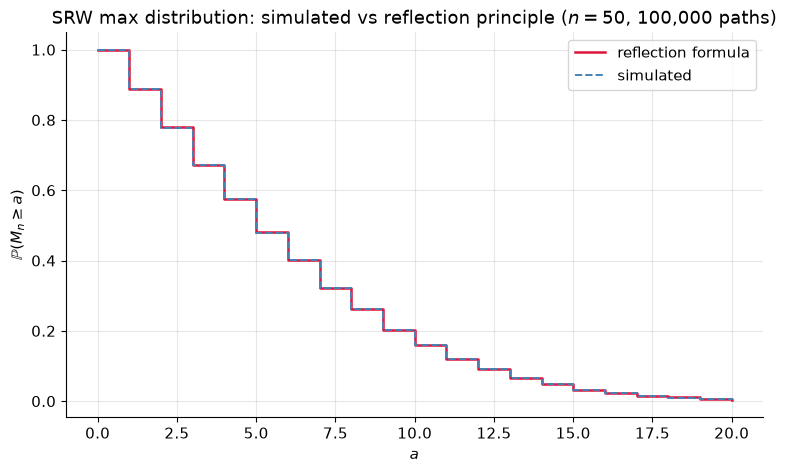

Max |simulated - formula| over a=0..20: 0.00213


In [2]:
# Demo 1: max of symmetric SRW — simulated CCDF vs reflection-principle formula
n_steps = 50
n_sims_max = 100_000
p_sym = 0.5

steps = rng.choice([-1, 1], size=(n_sims_max, n_steps), p=[1 - p_sym, p_sym])
paths = np.cumsum(steps, axis=1)
paths_with_start = np.hstack([np.zeros((n_sims_max, 1)), paths])
M_n_samples = paths_with_start.max(axis=1)


def P_Sn_ge(k, n, p):
    # P(S_n >= k) for a symmetric/biased SRW of n steps, any integer k.
    j_min = math.ceil((n + k) / 2)
    j_min = max(j_min, 0)
    if j_min > n:
        return 0.0
    return stats.binom.sf(j_min - 1, n, p)


def P_Mn_ge_reflection(a, n, p):
    # P(M_n >= a) via the reflection principle: P(S_n>=a) + P(S_n>a).
    return P_Sn_ge(a, n, p) + P_Sn_ge(a + 1, n, p)


a_values = np.arange(0, 21)
formula_ccdf = np.array([P_Mn_ge_reflection(a, n_steps, p_sym) for a in a_values])
empirical_ccdf = np.array([np.mean(M_n_samples >= a) for a in a_values])

fig, ax = plt.subplots()
ax.step(a_values, formula_ccdf, where="post", color="crimson", linewidth=1.8, label="reflection formula")
ax.step(a_values, empirical_ccdf, where="post", color="steelblue", linewidth=1.4, linestyle="--", label="simulated")
ax.set_xlabel("$a$")
ax.set_ylabel(r"$\mathbb{P}(M_n \geq a)$")
ax.set_title(f"SRW max distribution: simulated vs reflection principle ($n={n_steps}$, {n_sims_max:,} paths)")
ax.legend()
plt.show()

max_abs_diff = np.max(np.abs(formula_ccdf - empirical_ccdf))
print(f"Max |simulated - formula| over a=0..20: {max_abs_diff:.5f}")

Las dos curvas son visualmente indistinguibles: la frecuencia empírica de $\mathbb{P}(M_n \geq a)$ sobre $100\,000$ trayectorias sigue exactamente la fórmula de reflexión $\mathbb{P}(S_n\geq a)+\mathbb{P}(S_n>a)$, incluyendo el escalón en $a=0$ (donde $\mathbb{P}(M_n\geq 0)=1$ trivialmente, ya que $S_0=0$) y el decaimiento hacia la cola donde tocar $a=20$ en $50$ pasos requiere una racha muy favorable. La discrepancia máxima observada es del orden de $1/\sqrt{n_{\text{sims}}} \approx 0.003$, consistente con ruido de muestreo puro.

### Demo 2 — Cadena de 3 estados: convergencia de $\pi_0 P^n$ a la estacionaria

Fijamos la matriz de transición
$$
P = \begin{pmatrix} 0.5 & 0.3 & 0.2 \\ 0.2 & 0.6 & 0.2 \\ 0.3 & 0.3 & 0.4 \end{pmatrix},
$$
irreducible (todas las entradas son positivas, así que todo estado se comunica con todo estado) y aperiódica (diagonal estrictamente positiva). Calculamos su distribución estacionaria $\pi$ de dos formas independientes — resolviendo el sistema lineal $\pi P=\pi,\ \sum_i\pi_i=1$ y como el eigenvector izquierdo de $P$ asociado al eigenvalor $1$ — y graficamos la distancia en variación total $\text{TV}(\pi_0 P^n, \pi) = \tfrac12\sum_i|(\pi_0P^n)_i - \pi_i|$ en función de $n$ para $\pi_0 = (1,0,0)$.

pi (linear solve)  = [0.321429 0.428571 0.25    ]
pi (eigenvector)   = [0.321429 0.428571 0.25    ]
max |difference|   = 3.3306690738754696e-16


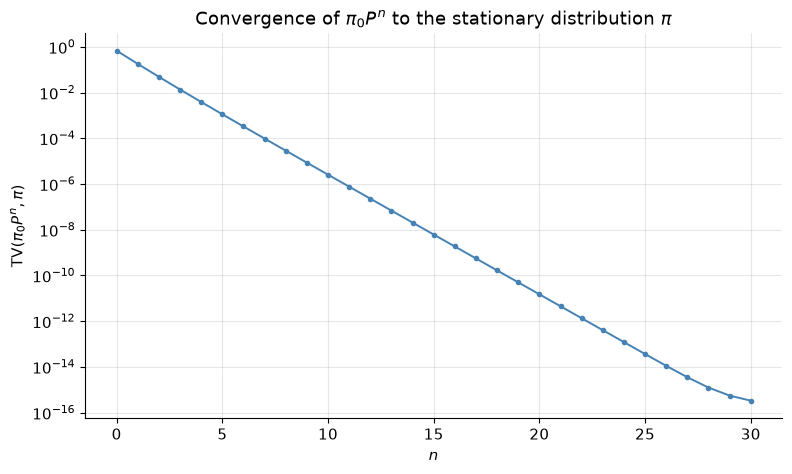

In [3]:
# Demo 2: 3-state Markov chain — stationary distribution (linear solve vs eigenvector) + TV convergence
P3 = np.array([
    [0.5, 0.3, 0.2],
    [0.2, 0.6, 0.2],
    [0.3, 0.3, 0.4],
])
assert np.allclose(P3.sum(axis=1), 1.0), "rows of P3 must sum to 1"

# Stationary distribution via linear system: (P^T - I) pi^T = 0, sum(pi) = 1
A = np.vstack([P3.T - np.eye(3), np.ones(3)])
b_vec = np.array([0.0, 0.0, 0.0, 1.0])
pi_linear, *_ = np.linalg.lstsq(A, b_vec, rcond=None)

# Stationary distribution via left eigenvector for eigenvalue 1: P^T v = v
eigvals, eigvecs = np.linalg.eig(P3.T)
idx_one = np.argmin(np.abs(eigvals - 1.0))
pi_eigen = np.real(eigvecs[:, idx_one])
pi_eigen = pi_eigen / pi_eigen.sum()

print("pi (linear solve)  =", np.round(pi_linear, 6))
print("pi (eigenvector)   =", np.round(pi_eigen, 6))
print("max |difference|   =", np.max(np.abs(pi_linear - pi_eigen)))

# Convergence of pi_0 P^n to pi (total variation distance)
pi0 = np.array([1.0, 0.0, 0.0])
n_max = 30
tv_distances = []
pi_n = pi0.copy()
for n in range(n_max + 1):
    tv_distances.append(0.5 * np.sum(np.abs(pi_n - pi_linear)))
    pi_n = pi_n @ P3

fig, ax = plt.subplots()
ax.semilogy(range(n_max + 1), np.maximum(tv_distances, 1e-16), marker="o", markersize=3, color="steelblue")
ax.set_xlabel("$n$")
ax.set_ylabel(r"TV$(\pi_0 P^n, \pi)$")
ax.set_title(r"Convergence of $\pi_0 P^n$ to the stationary distribution $\pi$")
plt.show()

Las dos formas de calcular $\pi$ —sistema lineal y eigenvector izquierdo de eigenvalor $1$— coinciden hasta precisión de máquina, como debe ser: son dos caracterizaciones algebraicas del mismo objeto ($\pi P=\pi \iff P^T\pi^T=\pi^T$). La distancia TV decae geométricamente con $n$ (línea recta en escala semilogarítmica) — la tasa de decaimiento está gobernada por el segundo eigenvalor de $P$ en módulo ($|\lambda_2|$), consistente con el teorema ergódico enunciado en la sección 2.3: partiendo de un estado puro ($\pi_0=(1,0,0)$), la cadena "olvida" su condición inicial exponencialmente rápido.

### Demo 3 — Ruina del jugador: simulación vs fórmula ($a=10$, $b=20$)

Simulamos la cadena de ruina del jugador con capital inicial $i=a=10$ y barrera superior $N=b=20$, para $p\in\{0.5, 0.48\}$, y comparamos la probabilidad de ruina simulada contra la fórmula cerrada de la sección 3.2.

In [4]:
# Demo 3: gambler's ruin — simulated vs formula, p in {0.5, 0.48}
i_start = 10
N_barrier = 20
n_sims_ruin = 100_000
max_steps_ruin = 5_000


def ruin_probability_formula(i, N, p):
    q = 1 - p
    if np.isclose(p, q):
        return (N - i) / N
    r = q / p
    return (r**i - r**N) / (1 - r**N)


def simulate_ruin_probability(i, N, p, n_sims, max_steps, rng):
    position = np.full(n_sims, i, dtype=np.int64)
    active = np.ones(n_sims, dtype=bool)
    for _ in range(max_steps):
        if not active.any():
            break
        step = rng.choice([1, -1], size=active.sum(), p=[p, 1 - p])
        position[active] += step
        active = (position > 0) & (position < N)
    ruined = position == 0
    assert not active.any(), "some paths did not absorb within max_steps"
    p_hat = ruined.mean()
    se = math.sqrt(p_hat * (1 - p_hat) / n_sims)
    return p_hat, se


results = {}
print(f"{'p':>5} | {'simulated':>10} | {'formula':>10} | {'SE':>8} | {'|diff|/SE':>10}")
print("-" * 55)
for p_ruin in (0.5, 0.48):
    p_hat, se = simulate_ruin_probability(i_start, N_barrier, p_ruin, n_sims_ruin, max_steps_ruin, rng)
    formula = ruin_probability_formula(i_start, N_barrier, p_ruin)
    results[p_ruin] = (p_hat, se, formula)
    print(f"{p_ruin:>5} | {p_hat:>10.5f} | {formula:>10.5f} | {se:>8.5f} | {abs(p_hat - formula) / se:>10.3f}")

    p |  simulated |    formula |       SE |  |diff|/SE
-------------------------------------------------------


  0.5 |    0.49877 |    0.50000 |  0.00158 |      0.778


 0.48 |    0.69139 |    0.69007 |  0.00146 |      0.907


Para $p=0.5$ (juego justo), la fórmula de ruina es lineal, $u_{10} = (20-10)/20 = 0.5$: sin deriva, el capital tiene la misma probabilidad de tocar $0$ que $20$ desde el punto medio. Para $p=0.48$ (ligera desventaja), $u_{10}$ sube por encima de $0.5$ — la deriva negativa hace la ruina más probable, aunque el efecto sobre la probabilidad es no lineal en $p$ (la fórmula involucra $r^i$ con $r=q/p>1$). En ambos casos la probabilidad simulada cae dentro de pocas desviaciones estándar de la fórmula cerrada, confirmando la derivación de la sección 3.2.

## 5. Validación

Verificamos formalmente dos resultados derivados arriba:

1. **Ruina del jugador:** la probabilidad de ruina simulada (demo 3, ambos valores de $p$) debe caer dentro de $3$ errores estándar (SE) de la fórmula cerrada $u_i = (r^i-r^N)/(1-r^N)$.
2. **Estacionariedad:** el $\pi$ calculado en la demo 2 debe satisfacer $\pi P = \pi$ con tolerancia absoluta $10^{-10}$.

In [5]:
# Validation: gambler's ruin within 3 SE of formula, and pi P = pi to atol 1e-10
for p_ruin, (p_hat, se, formula) in results.items():
    diff = abs(p_hat - formula)
    print(f"p={p_ruin}: |simulated - formula| = {diff:.6f}, 3*SE = {3*se:.6f}")
    assert diff <= 3 * se, f"gambler's ruin simulation for p={p_ruin} outside 3 SE of formula"

pi_check = pi_linear @ P3
max_stationary_error = np.max(np.abs(pi_check - pi_linear))
print(f"max |pi P - pi| = {max_stationary_error:.2e}")
assert np.allclose(pi_check, pi_linear, atol=1e-10), "pi P != pi within atol=1e-10"

print("Validation passed: gambler's ruin within 3 SE of formula (both p); pi P = pi to atol 1e-10.")

p=0.5: |simulated - formula| = 0.001230, 3*SE = 0.004743
p=0.48: |simulated - formula| = 0.001324, 3*SE = 0.004382
max |pi P - pi| = 2.22e-16
Validation passed: gambler's ruin within 3 SE of formula (both p); pi P = pi to atol 1e-10.


## Referencias

- Norris, J. R. (1997). *Markov Chains*. Cambridge University Press.
- Shreve, S. (2004). *Stochastic Calculus for Finance I: The Binomial Asset Pricing Model*, cap. 3.